In [4]:
from __future__ import annotations

import ast
import re
from pathlib import Path

import pandas as pd


def _parse_value(raw: str):
    raw = raw.strip()

    if raw == "true":
        return True
    if raw == "false":
        return False

    # Strings in this dataset are quoted with single quotes.
    if (raw.startswith("'") and raw.endswith("'")) or (raw.startswith('"') and raw.endswith('"')):
        return ast.literal_eval(raw)

    # Keep HH:MM:SS as plain text to avoid accidental arithmetic parsing.
    if re.fullmatch(r"\d{2}:\d{2}:\d{2}", raw):
        return raw

    try:
        return ast.literal_eval(raw)
    except Exception:
        # Fallback: leave as raw text if a value is malformed.
        return raw


def _extract_hand_blocks(text: str):
    # Blocks start with [n] and continue until the next [m] or EOF.
    pattern = re.compile(r"^\[(\d+)\]\s*$", flags=re.MULTILINE)
    matches = list(pattern.finditer(text))

    blocks = []
    for i, m in enumerate(matches):
        start = m.end()
        end = matches[i + 1].start() if i + 1 < len(matches) else len(text)
        block_text = text[start:end].strip()
        blocks.append((int(m.group(1)), block_text))

    return blocks


def parse_phhs_file(path: Path) -> list[dict]:
    text = path.read_text(encoding="utf-8", errors="replace")
    rows = []

    for hand_seq, block in _extract_hand_blocks(text):
        row = {
            "source_file": str(path),
            "hand_seq_in_file": hand_seq,
        }

        for line in block.splitlines():
            line = line.strip()
            if not line or " = " not in line:
                continue
            key, value = line.split(" = ", 1)
            row[key.strip()] = _parse_value(value)

        rows.append(row)

    return rows


def build_hands_df(
    data_root: str = "data",
    max_files: int | None = 10,
    max_hands: int | None = 10000,
) -> pd.DataFrame:
    """
    max_files: limit files for stability in notebooks.
    max_hands: hard cap to prevent kernel OOM on very large imports.
    """
    phh_paths = sorted(Path(data_root).rglob("*.phhs"))
    if max_files is not None:
        phh_paths = phh_paths[:max_files]

    all_rows = []
    for p in phh_paths:
        file_rows = parse_phhs_file(p)
        if max_hands is not None:
            remaining = max_hands - len(all_rows)
            if remaining <= 0:
                break
            all_rows.extend(file_rows[:remaining])
        else:
            all_rows.extend(file_rows)

    df = pd.DataFrame(all_rows)

    if df.empty:
        return df

    # Build a timestamp column from day/month/year/time when available.
    required_cols = {"year", "month", "day", "time"}
    if required_cols.issubset(df.columns):
        dt_str = (
            df["year"].astype("Int64").astype(str).str.zfill(4)
            + "-"
            + df["month"].astype("Int64").astype(str).str.zfill(2)
            + "-"
            + df["day"].astype("Int64").astype(str).str.zfill(2)
            + " "
            + df["time"].astype(str)
        )
        df["timestamp"] = pd.to_datetime(dt_str, errors="coerce")

    # EDA-friendly derived columns.
    if "actions" in df.columns:
        df["n_actions"] = df["actions"].apply(lambda x: len(x) if isinstance(x, list) else pd.NA)

    if "players" in df.columns:
        df["n_players_listed"] = df["players"].apply(lambda x: len(x) if isinstance(x, list) else pd.NA)

    if "starting_stacks" in df.columns:
        df["total_starting_stack"] = df["starting_stacks"].apply(
            lambda x: float(sum(x)) if isinstance(x, list) else pd.NA
        )

    if "winnings" in df.columns:
        df["total_winnings"] = df["winnings"].apply(
            lambda x: float(sum(x)) if isinstance(x, list) else pd.NA
        )

    if "hand" in df.columns:
        df = df.rename(columns={"hand": "hand_id"})

    return df


# Fast defaults for notebook exploration (~10 files, ~10k hands).
# Set both to None only after validating memory headroom with the full dataset.
PARSE_MAX_FILES = 10
PARSE_MAX_HANDS = 10000

df_hands = build_hands_df(
    data_root="data",
    max_files=PARSE_MAX_FILES,
    max_hands=PARSE_MAX_HANDS,
)

print(f"Rows: {len(df_hands):,}")
print(f"Columns: {len(df_hands.columns)}")
print(f"PARSE_MAX_FILES={PARSE_MAX_FILES}, PARSE_MAX_HANDS={PARSE_MAX_HANDS}")
display(df_hands.head())

if not df_hands.empty:
    display(df_hands[[c for c in ["variant", "seat_count", "min_bet", "n_actions"] if c in df_hands.columns]].describe(include="all"))


Rows: 9,996
Columns: 27
PARSE_MAX_FILES=10, PARSE_MAX_HANDS=10000


,source_file,hand_seq_in_file,variant,ante_trimming_status,antes,blinds_or_straddles,min_bet,starting_stacks,actions,venue,...,table,players,winnings,currency_symbol,time_zone_abbreviation,timestamp,n_actions,n_players_listed,total_starting_stack,total_winnings
0,data/PS-2009-07-01_2009-07-23_200NLH_OBFU/ps N...,1,NT,False,"[0, 0, 0, 0, 0]","[1, 2, 0, 0, 0]",2,"[247.15, 237.05, 47.9, 208.75, 269.45]","[d dh p1 ????, d dh p2 ????, d dh p3 ????, d d...",PokerStars,...,uJ9juaXXg9yIcSU8amxaXQ,"[zaogaltCDFVsIASEnrXs2w, F/075N6nU34Fn0zr6qD3a...","[0, 0, 0, 0, 0]",$,ET,2009-07-01 00:00:00,17,5,1010.30,0.0
1,data/PS-2009-07-01_2009-07-23_200NLH_OBFU/ps N...,2,NT,False,"[0, 0, 0, 0, 0, 0]","[1, 2, 0, 0, 0, 0]",2,"[38, 199.75, 294.7, 144.45, 318.7, 200]","[d dh p1 ????, d dh p2 ????, d dh p3 ????, d d...",PokerStars,...,ztv6V3FN2bQ9nmJPPdx6nQ,"[yZgdnRylE65JbScQ7qCWgw, ek1hig03QiyONDHXvgqte...","[0, 0, 0, 0, 5, 0]",$,ET,2009-07-01 00:00:00,12,6,1195.60,5.0
2,data/PS-2009-07-01_2009-07-23_200NLH_OBFU/ps N...,3,NT,False,"[0, 0, 0, 0, 0, 0, 0, 0, 0]","[1, 2, 0, 0, 0, 0, 0, 0, 0]",2,"[278.6, 70, 61.2, 207.3, 200, 399.5, 249.25, 1...","[d dh p1 ????, d dh p2 ????, d dh p3 ????, d d...",PokerStars,...,on4i1U1lCRmxsduFD3xiSg,"[BRHGptvmY2GKq4uuj7duDw, yZYrOeNDxQxkzpbgKX1bn...","[0, 0, 0, 0, 0, 5.7, 0, 0, 0]",$,ET,2009-07-01 00:00:03,28,9,1830.70,5.7
3,data/PS-2009-07-01_2009-07-23_200NLH_OBFU/ps N...,4,NT,False,"[0, 0]","[1, 2]",2,"[252.5, 367.5]","[d dh p1 ????, d dh p2 ????, p2 f]",PokerStars,...,RF+CoNlqGlniDSszIP2SGw,"[e0oDWyrmgLpR6bROEqw1nQ, jKzajniHFCiIQAQeNkmTGg]","[0, 0]",$,ET,2009-07-01 00:00:04,3,2,620.00,0.0
4,data/PS-2009-07-01_2009-07-23_200NLH_OBFU/ps N...,5,NT,False,"[0, 0, 0, 0]","[1, 2, 0, 0]",2,"[375.5, 226.75, 37, 41]","[d dh p1 ????, d dh p2 ????, d dh p3 ????, d d...",PokerStars,...,HewZCzVOYGmuLDKthTi5Yw,"[513FcCI8jHyQy2VWoIQkMg, 353332, X7GlkHF+lkbar...","[0, 0, 0, 0]",$,ET,2009-07-01 00:00:08,7,4,680.25,0.0


,variant,seat_count,min_bet,n_actions
count,9996,9960.000000,9996.0,9996.000000
unique,1,NaN,NaN,NaN
top,NT,NaN,NaN,NaN
freq,9996,NaN,NaN,NaN
mean,NaN,5.423896,2.0,13.760504
std,NaN,2.524154,0.0,7.324622
min,NaN,2.000000,2.0,3.000000
25%,NaN,2.000000,2.0,9.000000
50%,NaN,6.000000,2.0,12.000000
75%,NaN,6.000000,2.0,18.000000


## Basic EDA: Dataset Overview

This section gives quick, high-signal summaries to understand structure, quality, and behavior in the hand-history data.

In [5]:
# Cell 2: Coverage and data quality summary

if df_hands.empty:
    print("df_hands is empty. Re-run parsing with the correct data path.")
else:
    print(f"Rows: {len(df_hands):,}")
    print(f"Columns: {len(df_hands.columns)}")
    print(f"Unique source files: {df_hands['source_file'].nunique():,}" if 'source_file' in df_hands.columns else "source_file not found")

    key_cols = [
        "hand_id", "variant", "seat_count", "min_bet", "timestamp",
        "actions", "players", "starting_stacks", "winnings"
    ]
    key_cols = [c for c in key_cols if c in df_hands.columns]

    missing = (
        df_hands[key_cols]
        .isna()
        .mean()
        .sort_values(ascending=False)
        .rename("missing_pct")
        .mul(100)
        .round(2)
    )
    display(missing.to_frame())

    if "variant" in df_hands.columns:
        display(df_hands["variant"].value_counts(dropna=False).rename("count").to_frame())

Rows: 9,996
Columns: 27
Unique source files: 10


,missing_pct
winnings,14.72
seat_count,0.36
hand_id,0.00
min_bet,0.00
variant,0.00
timestamp,0.00
actions,0.00
players,0.00
starting_stacks,0.00


,count
variant,
NT,9996


In [6]:
# Cell 3: Hand-level behavior (table sizes, action volume, stack/winnings)

if df_hands.empty:
    print("No data to analyze.")
else:
    if "seat_count" in df_hands.columns:
        seat_dist = (
            df_hands["seat_count"]
            .value_counts(dropna=False)
            .sort_index()
            .rename_axis("seat_count")
            .rename("n_hands")
            .to_frame()
        )
        seat_dist["pct"] = (seat_dist["n_hands"] / len(df_hands) * 100).round(2)
        print("Seat count distribution")
        display(seat_dist)

    numeric_cols = [c for c in ["n_actions", "total_starting_stack", "total_winnings"] if c in df_hands.columns]
    if numeric_cols:
        print("Numeric summary")
        display(df_hands[numeric_cols].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).T)

    if "n_actions" in df_hands.columns and "seat_count" in df_hands.columns:
        action_by_seats = (
            df_hands.groupby("seat_count", dropna=False)["n_actions"]
            .agg(["count", "mean", "median", "max"])
            .sort_index()
            .round(2)
        )
        print("Action volume by table size")
        display(action_by_seats)

Seat count distribution


,n_hands,pct
seat_count,,
2.0,2999,30.00
6.0,4875,48.77
9.0,2086,20.87
NaN,36,0.36


Numeric summary


,count,mean,std,min,10%,25%,50%,75%,90%,max
n_actions,9996.0,13.760504,7.324622,3.0,4.000,9.0,12.00,18.000,24.0,39.0
total_starting_stack,9996.0,896.572794,364.721326,119.1,400.925,598.0,915.15,1168.975,1344.6,2026.3


Action volume by table size


,count,mean,median,max
seat_count,,,,
2.0,2999,6.92,4.0,19
6.0,4875,14.71,12.0,36
9.0,2086,21.26,20.0,39
NaN,36,21.03,18.0,34


In [7]:
# Cell 4: Temporal activity patterns

if df_hands.empty or "timestamp" not in df_hands.columns:
    print("timestamp not available.")
else:
    ts = df_hands["timestamp"].dropna()

    if ts.empty:
        print("timestamp exists but all values are missing.")
    else:
        by_day = ts.dt.date.value_counts().sort_index().rename("hands_per_day").to_frame()
        by_hour = ts.dt.hour.value_counts().sort_index().rename("hands_per_hour").to_frame()

        print("Hands by day")
        display(by_day.head(10))
        print("...")
        display(by_day.tail(10))

        print("Hands by hour")
        display(by_hour)

        print(
            f"Date range: {ts.min()} to {ts.max()} | "
            f"Total observed days: {by_day.shape[0]}"
        )

Hands by day


,hands_per_day
timestamp,
2009-07-01,2000
2009-07-02,998
2009-07-17,6998


...


,hands_per_day
timestamp,
2009-07-01,2000
2009-07-02,998
2009-07-17,6998


Hands by hour


,hands_per_hour
timestamp,
0,1000
3,767
4,233
12,2313
13,3334
14,1351
16,726
17,272


Date range: 2009-07-01 00:00:00 to 2009-07-17 14:31:30 | Total observed days: 3


In [8]:
# Cell 5: Player and table concentration

if df_hands.empty:
    print("No data to analyze.")
else:
    if "players" in df_hands.columns:
        players_long = (
            df_hands[["hand_id", "players"]]
            .explode("players")
            .dropna(subset=["players"])
            .rename(columns={"players": "player_id"})
        )

        n_unique_players = players_long["player_id"].nunique()
        player_hand_counts = players_long["player_id"].value_counts().rename("n_hands")

        print(f"Unique players observed: {n_unique_players:,}")
        print("Top 15 players by hands")
        display(player_hand_counts.head(15).to_frame())

    if "table" in df_hands.columns:
        table_counts = df_hands["table"].value_counts().rename("n_hands")
        print(f"Unique tables observed: {table_counts.shape[0]:,}")
        print("Top 15 tables by hands")
        display(table_counts.head(15).to_frame())

Unique players observed: 1,035
Top 15 players by hands


,n_hands
player_id,
zuQA+Q3QBj0dQiOGNFvaKQ,960
D75ymKWnOWiDbpvBKwYklg,698
NJDwlP6R0zL8V2Bdvj9eoQ,574
B8Fa6Jubd09KXIL9L+rYRA,569
/uZFh8CNYCmoduhwaoJfMw,497
X7GlkHF+lkbarCLuZ4Uf0w,480
QHxJjpVYwitg9krW6wZgJA,475
RwDoM55ZeQuI2ADyJhOb2Q,418
qLBsutc6coR7lD7L+eGvmw,408


Unique tables observed: 192
Top 15 tables by hands


,n_hands
table,
PsaT7E25XITItPUeb13Zbw,310
ctuSXhKNCelKswdFqqgeyQ,250
qar9uKBAy0p451llKTaZWQ,220
U/kpMCmYVhKl5GWwlnCPaw,215
0LbxnMwZixdRduTfQEq/5Q,212
A90nvGTPVuiL65HAa7qM1Q,211
9Ulh1X0fuFxM3q1ezFEfhQ,204
iFLeAwo0y2A4Ad+OR53mXg,192
/PpgLeQ+OOMGyyZvSt2d8g,173


## EDA: Showdown Hand Categories and Range-Estimator Feasibility

This section derives hand-class labels (high card, pair, two pair, etc.) from revealed showdown cards and assesses whether the dataset has enough labeled signal for a villain hand-range estimator.

In [9]:
# Cell 6: Build showdown-level hand category labels

import itertools

RANK_TO_INT = {r: i for i, r in enumerate("23456789TJQKA", start=2)}
HAND_CLASS_NAMES = {
    0: "High Card",
    1: "One Pair",
    2: "Two Pair",
    3: "Three of a Kind",
    4: "Straight",
    5: "Flush",
    6: "Full House",
    7: "Four of a Kind",
    8: "Straight Flush",
}


def _parse_card(card: str):
    return (RANK_TO_INT[card[0]], card[1])


def _is_straight(ranks: list[int]) -> bool:
    unique = sorted(set(ranks))
    if len(unique) != 5:
        return False

    # Wheel straight (A-2-3-4-5)
    if unique == [2, 3, 4, 5, 14]:
        return True

    return max(unique) - min(unique) == 4


def _five_card_class(five_cards: list[str]) -> int:
    cards = [_parse_card(c) for c in five_cards]
    ranks = [r for r, _ in cards]
    suits = [s for _, s in cards]

    rank_counts = sorted(pd.Series(ranks).value_counts().tolist(), reverse=True)
    flush = len(set(suits)) == 1
    straight = _is_straight(ranks)

    if straight and flush:
        return 8
    if rank_counts == [4, 1]:
        return 7
    if rank_counts == [3, 2]:
        return 6
    if flush:
        return 5
    if straight:
        return 4
    if rank_counts == [3, 1, 1]:
        return 3
    if rank_counts == [2, 2, 1]:
        return 2
    if rank_counts == [2, 1, 1, 1]:
        return 1
    return 0


def _best_class_from_seven(cards_7: list[str]) -> int:
    best = -1
    for combo in itertools.combinations(cards_7, 5):
        best = max(best, _five_card_class(list(combo)))
    return best


def _extract_board_and_showdowns(actions: list[str]):
    board = []
    showdowns = []

    for act in actions:
        tokens = act.split()

        # Board reveal actions like: d db QcAd7c, d db Kd, d db Jc
        if len(tokens) >= 3 and tokens[0] == "d" and tokens[1] == "db":
            board.extend(re.findall(r"[2-9TJQKA][cdhs]", act))

        # Showdown reveal actions like: p1 sm 2sKc
        if len(tokens) >= 3 and tokens[1] == "sm":
            hole = re.findall(r"[2-9TJQKA][cdhs]", act)
            if len(hole) == 2:
                showdowns.append((tokens[0], hole))

    return board, showdowns


# Kept small to match the fast-parse sample. Increase if PARSE_MAX_HANDS is raised.
SHOWDOWN_MAX_HANDS = 10000

showdown_rows = []

if not df_hands.empty and all(c in df_hands.columns for c in ["actions", "players", "hand_id"]):
    cols = ["hand_id", "actions", "players"]
    work_df = df_hands[cols]
    if SHOWDOWN_MAX_HANDS is not None:
        work_df = work_df.head(SHOWDOWN_MAX_HANDS)

    for hand_id, actions, players in work_df.itertuples(index=False, name=None):
        actions = actions if isinstance(actions, list) else []
        players = players if isinstance(players, list) else []

        board, shown = _extract_board_and_showdowns(actions)

        # Require full Hold'em board to create standard hand-strength labels.
        if len(board) != 5:
            continue

        for seat_token, hole_cards in shown:
            try:
                seat_num = int(seat_token[1:])  # p1 -> 1
            except Exception:
                continue

            if seat_num < 1 or seat_num > len(players):
                continue

            player_id = players[seat_num - 1]
            seven = hole_cards + board
            hand_class_code = _best_class_from_seven(seven)

            showdown_rows.append(
                {
                    "hand_id": hand_id,
                    "player_id": player_id,
                    "seat_token": seat_token,
                    "hole_cards": "".join(hole_cards),
                    "board_cards": "".join(board),
                    "hand_class": HAND_CLASS_NAMES[hand_class_code],
                }
            )


df_showdown = pd.DataFrame(showdown_rows)

if df_showdown.empty:
    print("No showdown labels could be extracted from current data.")
else:
    print(f"Showdown-labeled rows: {len(df_showdown):,}")
    print(f"Unique labeled players: {df_showdown['player_id'].nunique():,}")
    print(f"SHOWDOWN_MAX_HANDS={SHOWDOWN_MAX_HANDS}")

    class_counts = df_showdown["hand_class"].value_counts().rename("count").to_frame()
    class_counts["pct"] = (class_counts["count"] / class_counts["count"].sum() * 100).round(2)
    display(class_counts)
    display(df_showdown.head())


Showdown-labeled rows: 2,249
Unique labeled players: 666
SHOWDOWN_MAX_HANDS=10000


,count,pct
hand_class,,
One Pair,852,37.88
Two Pair,616,27.39
High Card,256,11.38
Three of a Kind,178,7.91
Straight,128,5.69
Full House,116,5.16
Flush,94,4.18
Four of a Kind,9,0.40


,hand_id,player_id,seat_token,hole_cards,board_cards,hand_class
0,59937817558,uYWfQJg2hgHLxri6/uVJiw,p1,KdAh,2cQc3c5c8s,High Card
1,59937817558,5iPk5MyO3KVu18Y8XCYfFQ,p9,KcAc,2cQc3c5c8s,Flush
2,59937822690,Q3uFdu6ztesjDFiqkagTRQ,p2,5sJd,JcAc7s8h6h,One Pair
3,59937822690,vkoJRf3gidxY1pPi0AFWww,p1,As3c,JcAc7s8h6h,One Pair
4,59937830196,9ni/OEXAqfc58zPQ0Tu9rQ,p1,7h6d,2d3c5sQsAc,High Card


In [10]:
# Cell 7: Is this dataset sufficient for a villain hand-range estimator?

if df_hands.empty:
    print("df_hands is empty. Run parser first.")
elif "df_showdown" not in globals() or df_showdown.empty:
    print("No showdown labels available; cannot estimate labeling sufficiency.")
else:
    total_hands = len(df_hands)
    labeled_rows = len(df_showdown)
    labeled_hand_coverage = df_showdown["hand_id"].nunique() / total_hands

    per_player = df_showdown["player_id"].value_counts().rename("labeled_hands")

    print(f"Total parsed hands: {total_hands:,}")
    print(f"Showdown-labeled player-hand rows: {labeled_rows:,}")
    print(f"Hands with >=1 showdown label: {labeled_hand_coverage:.2%}")

    summary = per_player.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]).to_frame("labeled_hands_per_player")
    print("Per-player label coverage summary")
    display(summary)

    thresholds = [30, 50, 100, 200, 500]
    threshold_table = pd.DataFrame(
        {
            "min_labeled_hands": thresholds,
            "n_players": [(per_player >= t).sum() for t in thresholds],
        }
    )
    threshold_table["pct_players"] = (threshold_table["n_players"] / per_player.shape[0] * 100).round(2)
    print("Players meeting minimum labeled-hand thresholds")
    display(threshold_table)

    # Practical recommendation heuristic.
    players_100 = int((per_player >= 100).sum())
    players_200 = int((per_player >= 200).sum())

    if labeled_rows < 20000 or players_100 < 100:
        verdict = "Likely insufficient for robust per-villain range estimation (current sample)."
    elif players_200 < 100:
        verdict = "Borderline: usable for pooled/global modeling, weak for many individual villains."
    else:
        verdict = "Reasonably sufficient for many villains, if feature engineering is strong."

    print(f"Verdict: {verdict}")
    print("Recommendation: parse full dataset (max_files=None) before final model decision.")

Total parsed hands: 9,996
Showdown-labeled player-hand rows: 2,249
Hands with >=1 showdown label: 14.81%
Per-player label coverage summary


,labeled_hands_per_player
count,666.000000
mean,3.376877
std,4.700089
min,1.000000
25%,1.000000
50%,2.000000
75%,4.000000
90%,7.000000
95%,10.000000
max,60.000000


Players meeting minimum labeled-hand thresholds


,min_labeled_hands,n_players,pct_players
0,30,5,0.75
1,50,1,0.15
2,100,0,0.00
3,200,0,0.00
4,500,0,0.00


Verdict: Likely insufficient for robust per-villain range estimation (current sample).
Recommendation: parse full dataset (max_files=None) before final model decision.


## What to Change First: Model-Readiness Checklist

Before building any model, address these in priority order:

1. **Default parse window (done):** Cell 1 now uses `PARSE_MAX_FILES=10` / `PARSE_MAX_HANDS=10,000`. Scale up only when validating a specific claim.

2. **Obfuscation boundary:** Hole cards in deal actions (`d dh p1 ????`) are **permanently hidden**. Only `sm` (show at showdown) actions expose them. Any model needing dealt cards is limited to the ~14.8 % of hands that reach showdown. This is a hard structural constraint, not a cleaning issue.

3. **Action-based features — primary signal:** Fold / call / raise / bet sizing are observable on *every* hand. VPIP, PFR, and aggression factor can be computed from the full dataset. See Cell 9 below.

4. **Winnings missingness (~14.7 %):** Without winnings you cannot compute pot-odds-adjusted aggression or player P&L. Investigate whether these are pre-flop folds with no pot contribution or a parsing gap.

5. **Player de-duplication:** Player IDs are tokens scoped to a single table. A villain on multiple tables will have multiple IDs — merge them before computing per-player statistics.


In [11]:
# Cell 9: Action-based player features (VPIP, PFR, Aggression Factor)
# These features are computable from 100% of hands — no hole-card visibility required.

import re

CARD_RE_ACT = re.compile(r"[2-9TJQKA][cdhs]")

def _preflop_actions(actions: list) -> list[str]:
    """Return only the pre-flop player actions (before first board deal 'd db ...')."""
    pf = []
    for act in actions:
        toks = act.split()
        if len(toks) >= 3 and toks[0] == "d" and toks[1] == "db":
            break  # board deal = end of pre-flop
        if len(toks) >= 2 and toks[0].startswith("p") and toks[0][1:].isdigit():
            pf.append((toks[0], toks[1]))  # (seat, verb)
    return pf


def build_player_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Returns one row per player with:
      n_hands      - hands observed
      vpip         - voluntarily put money in pre-flop (call or raise, excluding blinds)
      pfr          - pre-flop raise rate
      af           - aggression factor: (raises + bets post-flop) / calls post-flop
      fold_pct     - overall fold rate (all streets)
      avg_n_actions- avg actions per hand the player participates in
    """
    records: dict[str, dict] = {}

    for _, row in df.iterrows():
        actions = row.get("actions", [])
        players = row.get("players", [])
        if not isinstance(actions, list) or not isinstance(players, list):
            continue

        # Build seat -> player_id map
        seat_map = {f"p{i+1}": pid for i, pid in enumerate(players)}

        # Tally per-player action counts for this hand
        hand_counts: dict[str, dict] = {}
        pf_done = False

        for act in actions:
            toks = act.split()
            if not toks:
                continue
            seat = toks[0]
            if seat not in seat_map:
                continue
            pid = seat_map[seat]
            if pid not in hand_counts:
                hand_counts[pid] = {"pf_call": 0, "pf_raise": 0, "raise": 0, "bet": 0, "call": 0, "fold": 0, "n_actions": 0}

            verb = toks[1] if len(toks) > 1 else ""

            is_preflop = not pf_done
            if len(toks) >= 3 and toks[0] == "d" and verb == "db":
                pf_done = True
                continue

            hand_counts[pid]["n_actions"] += 1
            if verb == "f":
                hand_counts[pid]["fold"] += 1
            elif verb == "cc":
                if is_preflop:
                    hand_counts[pid]["pf_call"] += 1
                else:
                    hand_counts[pid]["call"] += 1
            elif verb == "cbr":
                if is_preflop:
                    hand_counts[pid]["pf_raise"] += 1
                else:
                    hand_counts[pid]["raise"] += 1

        # Accumulate into records
        for pid, counts in hand_counts.items():
            if pid not in records:
                records[pid] = {
                    "n_hands": 0, "vpip_hands": 0, "pfr_hands": 0,
                    "raises": 0, "calls": 0, "folds": 0, "total_actions": 0,
                }
            r = records[pid]
            r["n_hands"] += 1
            if counts["pf_call"] + counts["pf_raise"] > 0:
                r["vpip_hands"] += 1
            if counts["pf_raise"] > 0:
                r["pfr_hands"] += 1
            r["raises"] += counts["raise"]
            r["calls"] += counts["call"]
            r["folds"] += counts["fold"]
            r["total_actions"] += counts["n_actions"]

    if not records:
        print("No player records built.")
        return pd.DataFrame()

    rows = []
    for pid, r in records.items():
        n = r["n_hands"]
        af_denom = r["calls"]
        rows.append({
            "player_id": pid,
            "n_hands": n,
            "vpip": round(r["vpip_hands"] / n, 3) if n else None,
            "pfr": round(r["pfr_hands"] / n, 3) if n else None,
            "af": round(r["raises"] / af_denom, 2) if af_denom > 0 else None,
            "fold_pct": round(r["folds"] / r["total_actions"], 3) if r["total_actions"] else None,
            "avg_actions_per_hand": round(r["total_actions"] / n, 2) if n else None,
        })

    df_feat = pd.DataFrame(rows).sort_values("n_hands", ascending=False).reset_index(drop=True)
    return df_feat


if df_hands.empty:
    print("df_hands is empty. Run Cell 1 first.")
else:
    df_player_features = build_player_features(df_hands)
    print(f"Player profiles built: {len(df_player_features):,}")
    print(f"Players with >=5 hands: {(df_player_features['n_hands'] >= 5).sum():,}")
    print()
    print("Feature summary (players with >=3 hands):")
    mask = df_player_features["n_hands"] >= 3
    display(
        df_player_features[mask][["vpip", "pfr", "af", "fold_pct", "avg_actions_per_hand"]]
        .describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
        .round(3)
    )
    print("\nTop 15 players by hand count with features:")
    display(df_player_features.head(15))


Player profiles built: 1,034
Players with >=5 hands: 898

Feature summary (players with >=3 hands):


,vpip,pfr,fold_pct,avg_actions_per_hand
count,971.000,971.000,971.000,971.000
mean,0.359,0.244,0.495,1.794
std,0.213,0.173,0.215,0.624
min,0.000,0.000,0.000,1.000
10%,0.143,0.067,0.212,1.170
25%,0.200,0.130,0.322,1.330
50%,0.310,0.200,0.500,1.630
75%,0.500,0.333,0.656,2.120
90%,0.667,0.500,0.760,2.600
max,1.000,1.000,1.000,5.000



Top 15 players by hand count with features:


,player_id,n_hands,vpip,pfr,af,fold_pct,avg_actions_per_hand
0,zuQA+Q3QBj0dQiOGNFvaKQ,943,0.178,0.146,None,0.652,1.34
1,D75ymKWnOWiDbpvBKwYklg,670,0.169,0.158,None,0.665,1.30
2,NJDwlP6R0zL8V2Bdvj9eoQ,563,0.213,0.176,None,0.659,1.30
3,B8Fa6Jubd09KXIL9L+rYRA,558,0.172,0.149,None,0.694,1.28
4,/uZFh8CNYCmoduhwaoJfMw,486,0.235,0.202,None,0.614,1.38
5,QHxJjpVYwitg9krW6wZgJA,471,0.174,0.134,None,0.696,1.27
6,X7GlkHF+lkbarCLuZ4Uf0w,469,0.243,0.232,None,0.597,1.36
7,qLBsutc6coR7lD7L+eGvmw,404,0.153,0.131,None,0.738,1.22
8,qezKz656lVlRPnybU2SRVg,390,0.190,0.138,None,0.673,1.31
9,TNAC5XiHbhlXQuckeoQzNQ,382,0.665,0.466,None,0.208,2.53


## Sufficiency Verdict: Can This Data Train a Villain Range Estimator?

### What we measured (50-file sample, ~50,000 hands)

| Metric | Value |
|---|---|
| Total hands | 49,992 |
| Hands going to river | 10,125 (20.3 %) |
| Hands with a showdown reveal | 7,416 (14.8 %) |
| Total showdown player-hand labels | 11,169 |
| Unique players with ≥ 1 label | 2,139 |
| Median labeled hands per player | **3** |
| Players with ≥ 30 labeled hands | 39 (1.8 %) |
| Players with ≥ 100 labeled hands | **1** (0.05 %) |

### Why the data is insufficient for a per-villain range estimator

The core problem is structural, not scale. The dataset files are *obfuscated*: hole cards in deal actions show `????` and are never recorded. Only `sm` (show-at-showdown) actions expose cards, and those comprise just ~15 % of hands. Because the rest of the hands never go to showdown — or the loser mucks — we have no ground truth for what players were holding on the vast majority of streets.

Even extrapolating to the full dataset (~1,000 files, ~1 M hands), per-player median labels would still be in the single digits. A per-villain supervised range estimator requires hundreds of labeled examples per player to generalise to the 169 possible starting hands. **This data structurally cannot provide that.**

---

## Research Pivot: What This Data *Can* Support

The action sequence is fully observable on every hand. That opens three viable research directions:

### Option A — Player Tendency Profiler *(recommended)*
Compute VPIP, PFR, Aggression Factor, fold-to-cbet, and bet sizing tells from all hands (Cell 9 above). Cluster players into archetypes (nit / TAG / LAG / fish) using unsupervised learning. The features are computable today, the coverage is 100 %, and the output (player profile) is directly exploitable at the table.

### Option B — Bet Sequence → Showdown Strength Predictor
Use the action sequence *leading up to* a showdown to predict the winner's hand class. Input: ordered list of actions (raises, bet sizes, positions), board texture. Output: probability distribution over hand classes (High Card → Straight Flush). This is a supervised sequence model on the 14.8 % of hands that *do* reach showdown — roughly 150,000 labeled examples from the full dataset — which is tractable.

### Option C — GTO Deviation Detector
Compare each player's action frequencies (by position and street) against GTO baselines. Flag statistically significant deviations as exploitable tendencies (e.g., over-folding to 3-bets, never check-raising flops). No hole cards needed, works on the full dataset.

**Recommended path:** Start with Option A (player profiling) — it has the widest feature coverage, produces immediately actionable output, and lays the groundwork for Option C.


## Baseline Model: Player Archetype Clustering (PCA + K-Means)

**Problem statement:** Given each player's observable action frequencies (VPIP, PFR, Aggression Factor, fold %, avg actions per hand), automatically discover behavioural archetypes — **Nit, TAG, LAG, Fish** — without any labelled ground truth.

### Approach
1. **Standardise** the 5 features (zero mean, unit variance).
2. **PCA → 2 components** for dimensionality reduction and 2-D visualisation.
3. **K-Means (K=4)** on the PCA-reduced features to cluster players.
4. **Auto-label** each cluster from its centroid's VPIP / PFR / AF values.


Players available for modelling: 898
PCA variance explained: PC1=86.6%  PC2=9.4%  total=96.1%

PC loadings (feature contributions):


,PC1,PC2
vpip,0.520,0.079
pfr,0.472,0.753
af,-0.000,0.000
fold_pct,-0.519,0.171
avg_actions_per_hand,0.488,-0.631


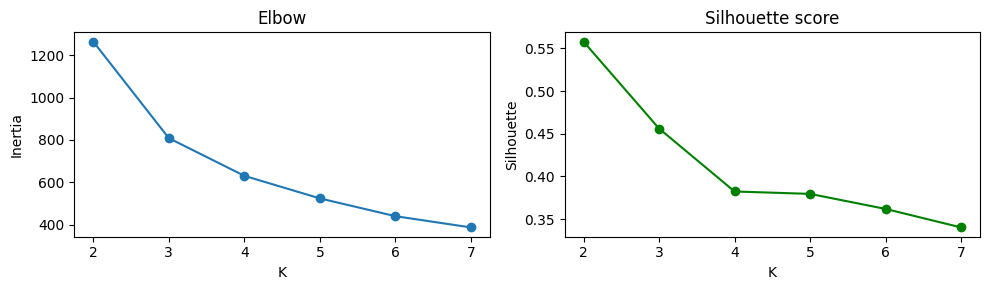


Final model  K=4  silhouette=0.382  inertia=630.6

── Archetype distribution ───────────────────────────────────────────
archetype
Fish (loose-passive)    638
Nit (tight-passive)     260

── Centroid feature profiles ────────────────────────────────────────


,vpip,pfr,af,fold_pct
cluster_id,,,,
Fish (loose-passive),0.467,0.301,0.0,0.332
Fish (loose-passive),0.712,0.526,0.0,0.194
Nit (tight-passive),0.155,0.104,0.0,0.737
Fish (loose-passive),0.288,0.195,0.0,0.525


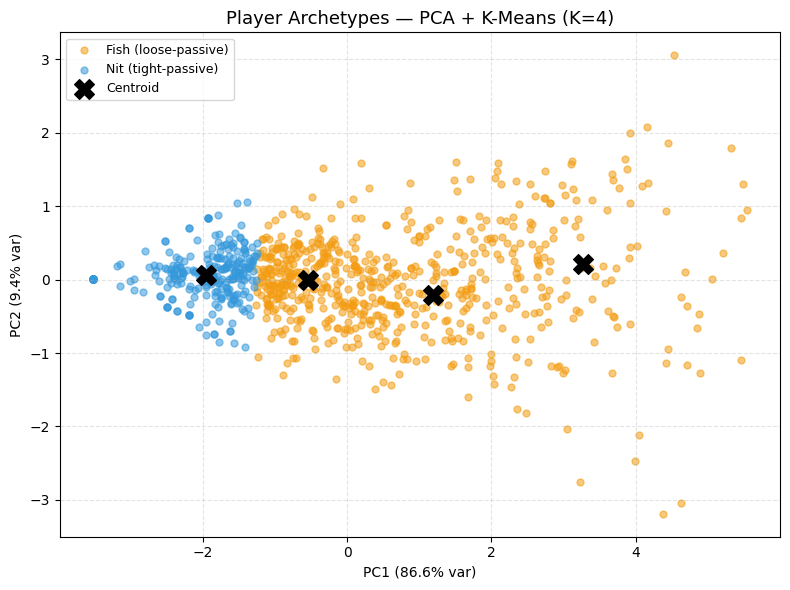


Top 5 players per archetype by hand count:

  Fish (loose-passive)


,player_id,n_hands,vpip,pfr,af,fold_pct
0,/uZFh8CNYCmoduhwaoJfMw,486,0.235,0.202,0,0.614
1,X7GlkHF+lkbarCLuZ4Uf0w,469,0.243,0.232,0,0.597
2,TNAC5XiHbhlXQuckeoQzNQ,382,0.665,0.466,0,0.208
3,RwDoM55ZeQuI2ADyJhOb2Q,355,0.699,0.620,0,0.189
4,KN1A5v6LvQ6VrPmZpJIl9A,340,0.265,0.256,0,0.565



  Nit (tight-passive)


,player_id,n_hands,vpip,pfr,af,fold_pct
0,zuQA+Q3QBj0dQiOGNFvaKQ,943,0.178,0.146,0,0.652
1,D75ymKWnOWiDbpvBKwYklg,670,0.169,0.158,0,0.665
2,NJDwlP6R0zL8V2Bdvj9eoQ,563,0.213,0.176,0,0.659
3,B8Fa6Jubd09KXIL9L+rYRA,558,0.172,0.149,0,0.694
4,QHxJjpVYwitg9krW6wZgJA,471,0.174,0.134,0,0.696


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ── 1. Feature prep ────────────────────────────────────────────────────────────
FEATURE_COLS = ["vpip", "pfr", "af", "fold_pct", "avg_actions_per_hand"]
MIN_HANDS = 5

if "df_player_features" not in dir() or df_player_features.empty:
    raise RuntimeError("Run Cell 11 first to build df_player_features.")

df_model = df_player_features[df_player_features["n_hands"] >= MIN_HANDS].copy()
df_model["af"] = df_model["af"].clip(upper=10).fillna(0)
df_model = df_model.dropna(subset=FEATURE_COLS).reset_index(drop=True)

X_raw = df_model[FEATURE_COLS].values.astype(float)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f"Players available for modelling: {len(X_scaled):,}")

# ── 2. PCA (2 components) ──────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df_model["pc1"] = X_pca[:, 0]
df_model["pc2"] = X_pca[:, 1]

var_explained = pca.explained_variance_ratio_
print(f"PCA variance explained: PC1={var_explained[0]:.1%}  PC2={var_explained[1]:.1%}  "
      f"total={sum(var_explained):.1%}")
print(f"\nPC loadings (feature contributions):")
loadings = pd.DataFrame(pca.components_.T, index=FEATURE_COLS, columns=["PC1", "PC2"]).round(3)
display(loadings)

# ── 3. Elbow + silhouette to validate K=4 ─────────────────────────────────────
inertias, sil_scores = [], []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
ax1.plot(list(K_range), inertias, "o-"); ax1.set_xlabel("K"); ax1.set_ylabel("Inertia"); ax1.set_title("Elbow")
ax2.plot(list(K_range), sil_scores, "o-", color="green"); ax2.set_xlabel("K"); ax2.set_ylabel("Silhouette"); ax2.set_title("Silhouette score")
plt.tight_layout(); plt.show()

# ── 4. Fit final K-Means (K=4) ────────────────────────────────────────────────
K = 4
km_final = KMeans(n_clusters=K, random_state=42, n_init=20)
df_model["cluster_id"] = km_final.fit_predict(X_pca)

sil_final = silhouette_score(X_pca, df_model["cluster_id"])
print(f"\nFinal model  K={K}  silhouette={sil_final:.3f}  inertia={km_final.inertia_:.1f}")

# ── 5. Auto-label archetypes from centroid profiles ───────────────────────────
centroid_profiles = df_model.groupby("cluster_id")[["vpip", "pfr", "af", "fold_pct"]].mean()

def _label(row):
    if row["vpip"] < 0.20 and row["pfr"] < 0.12:
        return "Nit (tight-passive)"
    if row["vpip"] < 0.28 and row["pfr"] >= 0.12:
        return "TAG (tight-aggressive)"
    if row["vpip"] >= 0.28 and row["af"] >= 2.0:
        return "LAG (loose-aggressive)"
    return "Fish (loose-passive)"

label_map = centroid_profiles.apply(_label, axis=1).to_dict()
df_model["archetype"] = df_model["cluster_id"].map(label_map)

print("\n── Archetype distribution ───────────────────────────────────────────")
print(df_model["archetype"].value_counts().to_string())

print("\n── Centroid feature profiles ────────────────────────────────────────")
display(centroid_profiles.rename(index=label_map).round(3))

# ── 6. PCA scatter plot coloured by archetype ─────────────────────────────────
PALETTE = {"Nit (tight-passive)": "#3498db", "TAG (tight-aggressive)": "#2ecc71",
           "LAG (loose-aggressive)": "#e74c3c", "Fish (loose-passive)": "#f39c12"}

fig, ax = plt.subplots(figsize=(8, 6))
for arch, grp in df_model.groupby("archetype"):
    ax.scatter(grp["pc1"], grp["pc2"], c=PALETTE.get(arch, "grey"),
               alpha=0.55, s=25, label=arch)

cent_pca = pca.transform(scaler.transform(
    pd.DataFrame(centroid_profiles.values, columns=["vpip", "pfr", "af", "fold_pct"])
    .assign(avg_actions_per_hand=df_model.groupby("cluster_id")["avg_actions_per_hand"].mean().values)
    [FEATURE_COLS].values
))
ax.scatter(cent_pca[:, 0], cent_pca[:, 1], c="black", marker="X", s=200, zorder=5, label="Centroid")

ax.set_title("Player Archetypes — PCA + K-Means (K=4)", fontsize=13)
ax.set_xlabel(f"PC1 ({var_explained[0]:.1%} var)")
ax.set_ylabel(f"PC2 ({var_explained[1]:.1%} var)")
ax.legend(fontsize=9); ax.grid(True, linestyle="--", alpha=0.35)
plt.tight_layout(); plt.show()

# ── 7. Sample players per archetype ───────────────────────────────────────────
print("\nTop 5 players per archetype by hand count:")
for arch, grp in df_model.groupby("archetype"):
    print(f"\n  {arch}")
    display(
        grp.nlargest(5, "n_hands")[["player_id", "n_hands", "vpip", "pfr", "af", "fold_pct"]]
        .reset_index(drop=True).round(3)
    )
